# 07 Three-Way Model Comparison and Error Analysis

This notebook extends `05_model_comparison_and_error_analysis.ipynb` to include **PubMedBERT** alongside **TF-IDF + Logistic Regression** and **BioBERT**, producing a complete three-way comparison.

**Research questions answered here:**

- Which model achieves the best test-set performance overall?
- Does PubMedBERT improve over BioBERT, and by how much?
- On which *kinds* of examples does each transformer win over the baseline?
- Where do all three models still fail together?
- Which examples are the most useful for qualitative discussion in the thesis?


## Setup


In [1]:
from pathlib import Path
import json

import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

In [2]:
PROJECT_ROOT = Path(r'C:\Users\ribam\Desktop\Reseach\Dataset')
OUTPUT_ROOT  = PROJECT_ROOT / 'output'
COMPARE_DIR  = OUTPUT_ROOT / 'model_comparison_three_way'
COMPARE_DIR.mkdir(parents=True, exist_ok=True)

# --- metrics JSON paths ---
TFIDF_METRICS_PATH     = OUTPUT_ROOT / 'tfidf_logreg_metrics.json'
BIOBERT_METRICS_PATH   = OUTPUT_ROOT / 'biobert_fakehealth_healthfact'   / 'biobert_metrics.json'
PUBMED_METRICS_PATH    = OUTPUT_ROOT / 'pubmedbert_fakehealth_healthfact' / 'pubmedbert_metrics.json'

# --- prediction CSV paths ---
TFIDF_PRED_PATH   = OUTPUT_ROOT / 'tfidf_logreg_test_predictions.csv'
BIOBERT_PRED_PATH = OUTPUT_ROOT / 'biobert_fakehealth_healthfact'   / 'biobert_test_predictions.csv'
PUBMED_PRED_PATH  = OUTPUT_ROOT / 'pubmedbert_fakehealth_healthfact' / 'pubmedbert_test_predictions.csv'

TFIDF_METRICS_PATH, BIOBERT_METRICS_PATH, PUBMED_METRICS_PATH

(WindowsPath('C:/Users/ribam/Desktop/Reseach/Dataset/output/tfidf_logreg_metrics.json'),
 WindowsPath('C:/Users/ribam/Desktop/Reseach/Dataset/output/biobert_fakehealth_healthfact/biobert_metrics.json'),
 WindowsPath('C:/Users/ribam/Desktop/Reseach/Dataset/output/pubmedbert_fakehealth_healthfact/pubmedbert_metrics.json'))

## 1. Load Metrics


In [3]:
with open(TFIDF_METRICS_PATH,   'r', encoding='utf-8') as f:
    tfidf_metrics = json.load(f)

with open(BIOBERT_METRICS_PATH, 'r', encoding='utf-8') as f:
    biobert_metrics = json.load(f)

with open(PUBMED_METRICS_PATH,  'r', encoding='utf-8') as f:
    pubmed_metrics = json.load(f)

print('TF-IDF model    :', tfidf_metrics['model'])
print('BioBERT model   :', biobert_metrics['model_name'])
print('PubMedBERT model:', pubmed_metrics['model_name'])

TF-IDF model    : TF-IDF + Logistic Regression
BioBERT model   : dmis-lab/biobert-base-cased-v1.1
PubMedBERT model: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext


## 2. Three-Way Metric Comparison Table


In [4]:
comparison_df = pd.DataFrame([
    {
        'model'         : 'TF-IDF + Logistic Regression',
        'dev_accuracy'  : tfidf_metrics['dev_metrics']['accuracy'],
        'dev_precision' : tfidf_metrics['dev_metrics']['precision'],
        'dev_recall'    : tfidf_metrics['dev_metrics']['recall'],
        'dev_f1'        : tfidf_metrics['dev_metrics']['f1'],
        'test_accuracy' : tfidf_metrics['test_metrics']['accuracy'],
        'test_precision': tfidf_metrics['test_metrics']['precision'],
        'test_recall'   : tfidf_metrics['test_metrics']['recall'],
        'test_f1'       : tfidf_metrics['test_metrics']['f1'],
    },
    {
        'model'         : 'BioBERT',
        'dev_accuracy'  : biobert_metrics['dev_metrics']['eval_accuracy'],
        'dev_precision' : biobert_metrics['dev_metrics']['eval_precision'],
        'dev_recall'    : biobert_metrics['dev_metrics']['eval_recall'],
        'dev_f1'        : biobert_metrics['dev_metrics']['eval_f1'],
        'test_accuracy' : biobert_metrics['test_metrics']['eval_accuracy'],
        'test_precision': biobert_metrics['test_metrics']['eval_precision'],
        'test_recall'   : biobert_metrics['test_metrics']['eval_recall'],
        'test_f1'       : biobert_metrics['test_metrics']['eval_f1'],
    },
    {
        'model'         : 'PubMedBERT',
        'dev_accuracy'  : pubmed_metrics['dev_metrics']['eval_accuracy'],
        'dev_precision' : pubmed_metrics['dev_metrics']['eval_precision'],
        'dev_recall'    : pubmed_metrics['dev_metrics']['eval_recall'],
        'dev_f1'        : pubmed_metrics['dev_metrics']['eval_f1'],
        'test_accuracy' : pubmed_metrics['test_metrics']['eval_accuracy'],
        'test_precision': pubmed_metrics['test_metrics']['eval_precision'],
        'test_recall'   : pubmed_metrics['test_metrics']['eval_recall'],
        'test_f1'       : pubmed_metrics['test_metrics']['eval_f1'],
    },
])

comparison_df.round(4)

,model,dev_accuracy,dev_precision,dev_recall,dev_f1,test_accuracy,test_precision,test_recall,test_f1
0,TF-IDF + Logistic Regression,0.6839,0.7756,0.6794,0.7243,0.6873,0.7713,0.6790,0.7222
1,BioBERT,0.7425,0.7339,0.9079,0.8116,0.7338,0.7290,0.8841,0.7991
2,PubMedBERT,0.7425,0.7841,0.7985,0.7912,0.7384,0.7908,0.7656,0.7780


In [5]:
comparison_df.to_csv(COMPARE_DIR / 'model_metric_comparison.csv', index=False)
print('Saved metric comparison to', COMPARE_DIR / 'model_metric_comparison.csv')

Saved metric comparison to C:\Users\ribam\Desktop\Reseach\Dataset\output\model_comparison_three_way\model_metric_comparison.csv


## 3. F1 / Accuracy Bar Chart (Test Set)

Side-by-side grouped bars for Accuracy, Precision, Recall, and F1 across all three models.


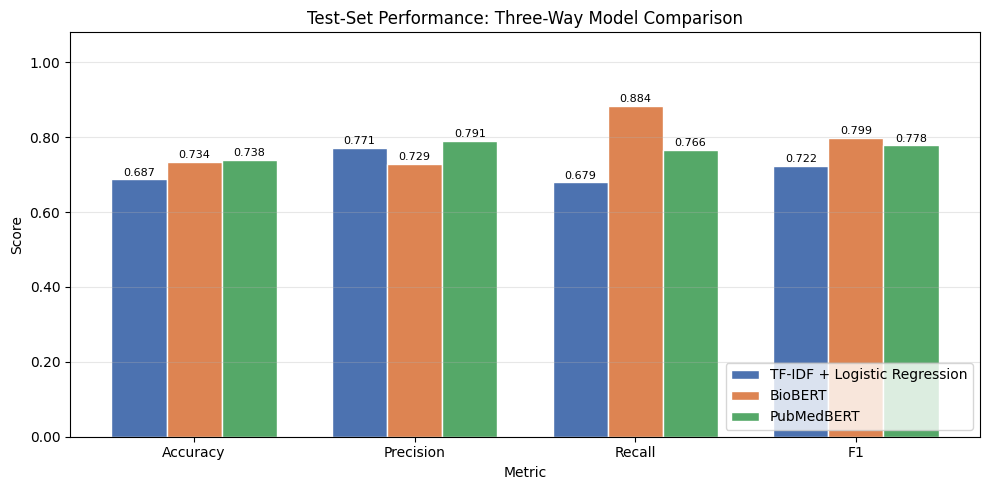

Saved bar chart to C:\Users\ribam\Desktop\Reseach\Dataset\output\model_comparison_three_way\test_metric_bar_chart.png


In [6]:
metrics_to_plot = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1']
metric_labels   = ['Accuracy', 'Precision', 'Recall', 'F1']
models          = comparison_df['model'].tolist()
colors          = ['#4C72B0', '#DD8452', '#55A868']   # TF-IDF, BioBERT, PubMedBERT

x     = np.arange(len(metric_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

for i, (model, color) in enumerate(zip(models, colors)):
    row    = comparison_df[comparison_df['model'] == model].iloc[0]
    values = [row[m] for m in metrics_to_plot]
    bars   = ax.bar(x + (i - 1) * width, values, width, label=model, color=color, edgecolor='white')
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=8
        )

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Test-Set Performance: Three-Way Model Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.08)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(COMPARE_DIR / 'test_metric_bar_chart.png', dpi=150)
plt.show()
print('Saved bar chart to', COMPARE_DIR / 'test_metric_bar_chart.png')

## 4. F1 Delta Table — Gains Over Baseline

Shows how much each transformer improves (or regresses) on each metric versus the TF-IDF baseline.


In [7]:
baseline = comparison_df[comparison_df['model'] == 'TF-IDF + Logistic Regression'].iloc[0]

delta_rows = []
for _, row in comparison_df[comparison_df['model'] != 'TF-IDF + Logistic Regression'].iterrows():
    delta_rows.append({
        'model'              : row['model'],
        'Δ test_accuracy'    : round(row['test_accuracy']  - baseline['test_accuracy'],  4),
        'Δ test_precision'   : round(row['test_precision'] - baseline['test_precision'], 4),
        'Δ test_recall'      : round(row['test_recall']    - baseline['test_recall'],    4),
        'Δ test_f1'          : round(row['test_f1']        - baseline['test_f1'],        4),
    })

delta_df = pd.DataFrame(delta_rows)
delta_df

,model,Δ test_accuracy,Δ test_precision,Δ test_recall,Δ test_f1
0,BioBERT,0.0465,-0.0424,0.2051,0.0769
1,PubMedBERT,0.0511,0.0194,0.0866,0.0558


In [8]:
delta_df.to_csv(COMPARE_DIR / 'delta_vs_baseline.csv', index=False)
print('Saved delta table to', COMPARE_DIR / 'delta_vs_baseline.csv')

Saved delta table to C:\Users\ribam\Desktop\Reseach\Dataset\output\model_comparison_three_way\delta_vs_baseline.csv


## 5. Merge All Three Prediction Files

We join on `(dataset, split, record_id, label, text)` — the same key used in notebook 05 — so every row represents one test example with all three model predictions side-by-side.


In [9]:
JOIN_KEYS = ['dataset', 'split', 'record_id', 'label', 'text']

tfidf_pred  = pd.read_csv(TFIDF_PRED_PATH)
biobert_pred = pd.read_csv(BIOBERT_PRED_PATH)
pubmed_pred  = pd.read_csv(PUBMED_PRED_PATH)

tfidf_pred   = tfidf_pred.rename(columns={'prediction': 'tfidf_prediction'})
biobert_pred = biobert_pred.rename(columns={
    'prediction'  : 'biobert_prediction',
    'prob_class_0': 'biobert_prob_0',
    'prob_class_1': 'biobert_prob_1',
})
pubmed_pred  = pubmed_pred.rename(columns={
    'prediction'  : 'pubmed_prediction',
    'prob_class_0': 'pubmed_prob_0',
    'prob_class_1': 'pubmed_prob_1',
})

merged = (
    tfidf_pred[JOIN_KEYS + ['tfidf_prediction']]
    .merge(
        biobert_pred[JOIN_KEYS + ['biobert_prediction', 'biobert_prob_0', 'biobert_prob_1']],
        on=JOIN_KEYS, how='inner'
    )
    .merge(
        pubmed_pred[JOIN_KEYS + ['pubmed_prediction', 'pubmed_prob_0', 'pubmed_prob_1']],
        on=JOIN_KEYS, how='inner'
    )
)

print('Merged rows:', len(merged))
merged.head(3)

Merged rows: 1311


,dataset,split,record_id,label,text,tfidf_prediction,biobert_prediction,biobert_prob_0,biobert_prob_1,pubmed_prediction,pubmed_prob_0,pubmed_prob_1
0,healthfact,test,33456,0,A mother revealed to her child in a letter aft...,0,1,0.320590,0.679410,0,0.839327,0.160673
1,healthfact,test,2542,1,Study says too many Americans still drink too ...,1,1,0.343338,0.656662,0,0.838512,0.161488
2,healthfact,test,26678,1,Viral image Says 80% of novel coronavirus case...,0,1,0.467584,0.532416,0,0.657698,0.342302


## 6. Eight-Bucket Analysis

With three binary correct/wrong signals there are **2³ = 8 possible buckets**. Naming convention: a bucket name lists the model(s) that got the example *correct*; `all_wrong` means all three failed.

| Bucket | TF-IDF | BioBERT | PubMedBERT |
|---|:---:|:---:|:---:|
| `all_correct` | ✓ | ✓ | ✓ |
| `tfidf_biobert_only` | ✓ | ✓ | ✗ |
| `tfidf_pubmed_only` | ✓ | ✗ | ✓ |
| `biobert_pubmed_only` | ✗ | ✓ | ✓ |
| `tfidf_only` | ✓ | ✗ | ✗ |
| `biobert_only` | ✗ | ✓ | ✗ |
| `pubmed_only` | ✗ | ✗ | ✓ |
| `all_wrong` | ✗ | ✗ | ✗ |


In [10]:
merged['tfidf_correct']   = merged['tfidf_prediction']  == merged['label']
merged['biobert_correct'] = merged['biobert_prediction'] == merged['label']
merged['pubmed_correct']  = merged['pubmed_prediction']  == merged['label']

t = merged['tfidf_correct']
b = merged['biobert_correct']
p = merged['pubmed_correct']

conditions = [
    ( t &  b &  p, 'all_correct'),
    ( t &  b & ~p, 'tfidf_biobert_only'),
    ( t & ~b &  p, 'tfidf_pubmed_only'),
    (~t &  b &  p, 'biobert_pubmed_only'),
    ( t & ~b & ~p, 'tfidf_only'),
    (~t &  b & ~p, 'biobert_only'),
    (~t & ~b &  p, 'pubmed_only'),
    (~t & ~b & ~p, 'all_wrong'),
]

merged['bucket'] = 'unassigned'
for mask, name in conditions:
    merged.loc[mask, 'bucket'] = name

bucket_counts = merged['bucket'].value_counts().reindex(
    [name for _, name in conditions], fill_value=0
)
bucket_counts

bucket
all_correct            327
tfidf_biobert_only     165
tfidf_pubmed_only      178
biobert_pubmed_only    130
tfidf_only             231
biobert_only            98
pubmed_only             79
all_wrong              103
Name: count, dtype: int64

In [11]:
bucket_summary = pd.DataFrame({
    'bucket' : bucket_counts.index,
    'count'  : bucket_counts.values,
    'percent': (bucket_counts.values / len(merged) * 100).round(2),
})
bucket_summary

,bucket,count,percent
0,all_correct,327,24.94
1,tfidf_biobert_only,165,12.59
2,tfidf_pubmed_only,178,13.58
3,biobert_pubmed_only,130,9.92
4,tfidf_only,231,17.62
5,biobert_only,98,7.48
6,pubmed_only,79,6.03
7,all_wrong,103,7.86


In [12]:
bucket_summary.to_csv(COMPARE_DIR / 'eight_bucket_summary.csv', index=False)
print('Saved bucket summary to', COMPARE_DIR / 'eight_bucket_summary.csv')

Saved bucket summary to C:\Users\ribam\Desktop\Reseach\Dataset\output\model_comparison_three_way\eight_bucket_summary.csv


### 6a. Bucket Bar Chart


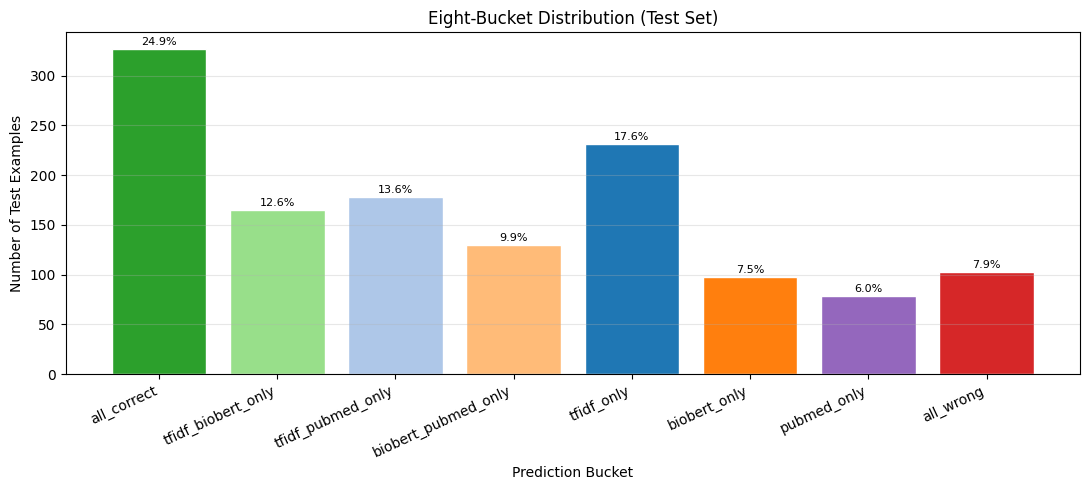

Saved bucket bar chart.


In [13]:
bucket_colors = [
    '#2ca02c',  # all_correct         — green
    '#98df8a',  # tfidf_biobert_only
    '#aec7e8',  # tfidf_pubmed_only
    '#ffbb78',  # biobert_pubmed_only
    '#1f77b4',  # tfidf_only          — blue
    '#ff7f0e',  # biobert_only        — orange
    '#9467bd',  # pubmed_only         — purple
    '#d62728',  # all_wrong           — red
]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(bucket_summary['bucket'], bucket_summary['count'], color=bucket_colors, edgecolor='white')
for bar, pct in zip(bars, bucket_summary['percent']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f'{pct:.1f}%',
        ha='center', va='bottom', fontsize=8
    )
ax.set_xlabel('Prediction Bucket')
ax.set_ylabel('Number of Test Examples')
ax.set_title('Eight-Bucket Distribution (Test Set)')
plt.xticks(rotation=25, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(COMPARE_DIR / 'eight_bucket_bar_chart.png', dpi=150)
plt.show()
print('Saved bucket bar chart.')

## 7. Per-Dataset and Per-Label Breakdown


In [14]:
dataset_bucket = pd.crosstab(merged['dataset'], merged['bucket'])
label_bucket   = pd.crosstab(merged['label'],   merged['bucket'])

print('--- By Source Dataset ---')
display(dataset_bucket)

print('\n--- By True Label (0 = misinfo, 1 = reliable) ---')
display(label_bucket)

--- By Source Dataset ---


bucket,all_correct,all_wrong,biobert_only,biobert_pubmed_only,pubmed_only,tfidf_biobert_only,tfidf_only,tfidf_pubmed_only
dataset,,,,,,,,
fakehealth,48,27,41,53,31,36,53,35
healthfact,279,76,57,77,48,129,178,143



--- By True Label (0 = misinfo, 1 = reliable) ---


bucket,all_correct,all_wrong,biobert_only,biobert_pubmed_only,pubmed_only,tfidf_biobert_only,tfidf_only,tfidf_pubmed_only
label,,,,,,,,
0,57,70,20,24,44,46,150,115
1,270,33,78,106,35,119,81,63


In [15]:
dataset_bucket.to_csv(COMPARE_DIR / 'dataset_bucket_crosstab.csv')
label_bucket.to_csv(COMPARE_DIR / 'label_bucket_crosstab.csv')
print('Saved crosstabs.')

Saved crosstabs.


## 8. Per-Model Accuracy by Dataset

A quick sanity check: does one model do systematically better on FakeHealth vs HealthFact?


In [16]:
per_dataset_acc = []
for ds in ['fakehealth', 'healthfact']:
    sub = merged[merged['dataset'] == ds]
    per_dataset_acc.append({
        'dataset'          : ds,
        'n'                : len(sub),
        'tfidf_accuracy'   : (sub['tfidf_correct'].sum()   / len(sub)).round(4),
        'biobert_accuracy' : (sub['biobert_correct'].sum() / len(sub)).round(4),
        'pubmed_accuracy'  : (sub['pubmed_correct'].sum()  / len(sub)).round(4),
    })

per_dataset_acc_df = pd.DataFrame(per_dataset_acc)
per_dataset_acc_df

,dataset,n,tfidf_accuracy,biobert_accuracy,pubmed_accuracy
0,fakehealth,324,0.5309,0.5494,0.5154
1,healthfact,987,0.7386,0.5491,0.5542


In [17]:
per_dataset_acc_df.to_csv(COMPARE_DIR / 'per_dataset_accuracy.csv', index=False)
print('Saved per-dataset accuracy.')

Saved per-dataset accuracy.


## 9. Qualitative Error Analysis

We pull out four sets of examples that are the most useful for thesis discussion:

1. **Both transformers win** (`biobert_pubmed_only`) — cases where domain knowledge clearly helps.
2. **PubMedBERT only wins** (`pubmed_only`) — cases where PubMedBERT's from-scratch biomedical pre-training gives it an edge over even BioBERT.
3. **TF-IDF only wins** (`tfidf_only`) — cases where lexical pattern matching beats deep contextual models.
4. **All three wrong** (`all_wrong`) — the hardest examples; useful for discussing the limits of current NLP approaches to health misinformation.


In [18]:
QUAL_COLS = [
    'dataset', 'record_id', 'label',
    'tfidf_prediction', 'biobert_prediction', 'pubmed_prediction',
    'biobert_prob_1', 'pubmed_prob_1',
    'text',
]

both_transformers_win = merged[merged['bucket'] == 'biobert_pubmed_only'][QUAL_COLS].copy()
pubmed_only_wins      = merged[merged['bucket'] == 'pubmed_only'][QUAL_COLS].copy()
tfidf_only_wins       = merged[merged['bucket'] == 'tfidf_only'][QUAL_COLS].copy()
all_wrong             = merged[merged['bucket'] == 'all_wrong'][QUAL_COLS].copy()

print('Both transformers win (biobert_pubmed_only):', len(both_transformers_win))
print('PubMedBERT only wins (pubmed_only)          :', len(pubmed_only_wins))
print('TF-IDF only wins (tfidf_only)               :', len(tfidf_only_wins))
print('All three wrong (all_wrong)                 :', len(all_wrong))

Both transformers win (biobert_pubmed_only): 130
PubMedBERT only wins (pubmed_only)          : 79
TF-IDF only wins (tfidf_only)               : 231
All three wrong (all_wrong)                 : 103


In [19]:
print('=== Both Transformers Win (sample 10) ===')
both_transformers_win.head(10)

=== Both Transformers Win (sample 10) ===


,dataset,record_id,label,tfidf_prediction,biobert_prediction,pubmed_prediction,biobert_prob_1,pubmed_prob_1,text
31,healthfact,760,1,0,1,1,0.675245,0.998951,"Suicide kills one person every 40 seconds, say..."
41,healthfact,13528,1,0,1,1,0.577517,0.976772,"Heroin comes in the United States ""from the so..."
46,healthfact,12009,1,0,1,1,0.730966,0.609171,One in 10 babies born in this country is born ...
49,healthfact,33288,0,1,0,0,0.220039,0.330332,A few drops of Visine brand eye drops taken in...
82,healthfact,33983,0,1,0,0,0.255243,0.001047,NASA and NOAA faked climate data in the GISTEM...
90,healthfact,26657,0,1,0,0,0.177028,0.005655,The WHO coronavirus test “was a bad test.”
95,healthfact,15867,0,1,0,0,0.130433,0.000968,Drug Policy Alliance Says Debbie Wasserman Sch...
106,healthfact,16846,1,0,1,1,0.997228,0.999908,After Massachusetts passed a mandatory health ...
120,healthfact,12493,1,0,1,1,0.997830,0.999922,"An ""abortion procedure is actually safer than ..."
125,healthfact,27280,1,0,1,1,0.998037,0.999921,A Russian asbestos company placed a seal with ...


In [20]:
print('=== PubMedBERT Only Wins (sample 10) ===')
pubmed_only_wins.head(10)

=== PubMedBERT Only Wins (sample 10) ===


,dataset,record_id,label,tfidf_prediction,biobert_prediction,pubmed_prediction,biobert_prob_1,pubmed_prob_1,text
13,healthfact,26248,0,1,1,0,0.652233,0.211416,“While California is dying … Gavin (Newsom) is...
19,healthfact,11523,0,1,1,0,0.762970,0.007882,Study suggests a second LDL test
21,healthfact,17064,0,1,1,0,0.649244,0.037696,A lot of the problems with forest fires ... is...
26,healthfact,10690,0,1,1,0,0.612071,0.081289,Treating First Time Shoulder Dislocations with...
40,healthfact,31219,0,1,1,0,0.583908,0.426145,Accepting a friend request from a stranger wil...
67,healthfact,5571,1,0,0,1,0.285624,0.928179,CVI: The impairment affecting children whose e...
76,healthfact,35389,1,0,0,1,0.383322,0.950860,Some grocery store receipts contain chemicals ...
134,healthfact,24357,1,0,0,1,0.416541,0.999418,"More than 1,000 people ... move to Texas every..."
167,healthfact,27236,1,0,0,1,0.223493,0.999933,A photograph shows the Arch of Baal erected on...
188,healthfact,18469,0,1,1,0,0.997911,0.195275,Abortionists have reduced our black population...


In [21]:
print('=== TF-IDF Only Wins (sample 10) ===')
tfidf_only_wins.head(10)

=== TF-IDF Only Wins (sample 10) ===


,dataset,record_id,label,tfidf_prediction,biobert_prediction,pubmed_prediction,biobert_prob_1,pubmed_prob_1,text
8,healthfact,32840,0,0,1,1,0.661080,0.979445,The media covered up an incident in San Bernar...
9,healthfact,33851,0,0,1,1,0.531339,0.559208,The mayonnaise oozing from a chicken sandwich ...
11,healthfact,29964,0,0,1,1,0.701216,0.835615,A film producer claimed actor Kevin Spacey had...
14,healthfact,1356,1,1,0,0,0.451315,0.089999,Britain backs GSK's gene therapy for 'bubble b...
16,healthfact,933,1,1,0,0,0.490237,0.104465,South Korea court strikes down abortion law in...
22,healthfact,37855,0,0,1,1,0.679216,0.963480,"United States President Donald Trump tweeted ""..."
23,healthfact,10667,0,0,1,1,0.668343,0.988516,Artificial Pancreas Continues to Show Promise
27,healthfact,9472,1,1,0,0,0.407829,0.167013,"Novartis hopeful for novel heart drug, despite..."
32,healthfact,32419,0,0,1,1,0.777603,0.998570,Photographs show a boy having his arm crushed ...
36,healthfact,30868,0,0,1,1,0.565835,0.975865,A Time magazine cover from 1977 with the title...


In [22]:
print('=== All Three Wrong (sample 10) ===')
all_wrong.head(10)

=== All Three Wrong (sample 10) ===


,dataset,record_id,label,tfidf_prediction,biobert_prediction,pubmed_prediction,biobert_prob_1,pubmed_prob_1,text
38,healthfact,11042,0,1,1,1,0.515670,0.856891,Strobe lighting provides a flicker of hope in ...
60,healthfact,10970,1,0,0,0,0.481394,0.031614,"To reverse damage of sitting, take a brisk, ho..."
62,healthfact,30893,0,1,1,1,0.746051,0.641822,A teenage schoolgirl in Texas became pregnant ...
65,healthfact,3478,1,0,0,0,0.426157,0.000604,"Lamont fills top public health, insurance agen..."
69,healthfact,28092,1,0,0,0,0.277578,0.004324,Immigration authorities are taking rosaries aw...
87,healthfact,16374,1,0,0,0,0.084472,0.001107,In the last six years of Cianci’s administrati...
89,healthfact,27567,1,0,0,0,0.161636,0.145692,The FDA has updated its warnings for — and rec...
92,healthfact,20583,1,0,0,0,0.096220,0.002078,On mandatory ultrasounds before abortions.
96,healthfact,2654,1,0,0,0,0.169647,0.014965,French breast implant boss arrested.
100,healthfact,9673,0,1,1,1,0.681843,0.999935,'Female Viagra' gets mixed reviews


In [23]:
both_transformers_win.to_csv(COMPARE_DIR / 'both_transformers_win_examples.csv',  index=False)
pubmed_only_wins.to_csv(     COMPARE_DIR / 'pubmed_only_correct_examples.csv',    index=False)
tfidf_only_wins.to_csv(      COMPARE_DIR / 'tfidf_only_correct_examples.csv',     index=False)
all_wrong.to_csv(            COMPARE_DIR / 'all_wrong_examples.csv',              index=False)
merged.to_csv(               COMPARE_DIR / 'full_merged_predictions.csv',         index=False)
print('Saved all qualitative analysis CSVs.')

Saved all qualitative analysis CSVs.


## 10. Summary JSON


In [24]:
best_model = comparison_df.sort_values('test_f1', ascending=False).iloc[0]

summary = {
    'best_model_by_test_f1' : best_model['model'],
    'test_f1_scores' : {
        row['model']: round(row['test_f1'], 6)
        for _, row in comparison_df.iterrows()
    },
    'f1_gain_biobert_over_tfidf'  : round(
        float(comparison_df.loc[comparison_df['model'] == 'BioBERT',    'test_f1'].iloc[0]) -
        float(comparison_df.loc[comparison_df['model'] == 'TF-IDF + Logistic Regression', 'test_f1'].iloc[0]),
        6
    ),
    'f1_gain_pubmed_over_tfidf'   : round(
        float(comparison_df.loc[comparison_df['model'] == 'PubMedBERT', 'test_f1'].iloc[0]) -
        float(comparison_df.loc[comparison_df['model'] == 'TF-IDF + Logistic Regression', 'test_f1'].iloc[0]),
        6
    ),
    'f1_gain_pubmed_over_biobert' : round(
        float(comparison_df.loc[comparison_df['model'] == 'PubMedBERT', 'test_f1'].iloc[0]) -
        float(comparison_df.loc[comparison_df['model'] == 'BioBERT',    'test_f1'].iloc[0]),
        6
    ),
    'bucket_counts' : bucket_summary.set_index('bucket')['count'].to_dict(),
    'total_test_examples' : int(len(merged)),
}

(COMPARE_DIR / 'comparison_summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
summary

{'best_model_by_test_f1': 'BioBERT',
 'test_f1_scores': {'TF-IDF + Logistic Regression': 0.722222,
  'BioBERT': 0.799079,
  'PubMedBERT': 0.777994},
 'f1_gain_biobert_over_tfidf': 0.076857,
 'f1_gain_pubmed_over_tfidf': 0.055771,
 'f1_gain_pubmed_over_biobert': -0.021085,
 'bucket_counts': {'all_correct': 327,
  'tfidf_biobert_only': 165,
  'tfidf_pubmed_only': 178,
  'biobert_pubmed_only': 130,
  'tfidf_only': 231,
  'biobert_only': 98,
  'pubmed_only': 79,
  'all_wrong': 103},
 'total_test_examples': 1311}

## Next Step

The natural follow-on after this three-way comparison is:

- **`08_single_claim_inference.ipynb`** — a demo/testing notebook that loads the best-performing fine-tuned model and classifies a user-supplied health claim in real time, with confidence scores. This is the second option originally listed at the end of `05_model_comparison_and_error_analysis.ipynb`.
